# <u>SVM-Linearly separable case</u>

## Topics

* [0. Basics](#basics)
* [1. Core idea](#idea)
* [2. Constrained optimization problems](#optim)
    * [2.1 ]
* [3. Implement linear separable SVM](#implement)


In [1]:
import numpy as np # for random numbers and math
import matplotlib.pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
print("Setup complete")

Setup complete


<a class="anchor" id="basics"></a>
# 0. Basics

## Goal: 

### Seperate two classes with a decision boundary (i.e. a line (one-dimensional), plane (two dimensional), or hyperplane (more than two dimensions))

## Problem (for exapmle with lines):

### Not every line that would otherwise be a valid decision boundary can be expressed as $y=mx + b$ called the slope-intercept form.

<p align="center">
<img src="pics/1.jpg" width="500"/>
</p>

## Solution (for exapmle with lines): 

### Use general form $Ax + By + C=z$ for the separating line

<p align="center">
<img src="pics/2.jpg" width="500"/>
</p>

### Properties of general form $Ax+By+C=z$:

- **Express a vertical line with $Ax + 0y + C = z \Leftrightarrow x=-\frac{C}{A}$ independent of $y$**

- **$Ax + By + C = z$ and $k \cdot Ax + k \cdot By + k \cdot C = k \cdot z$ for a scalar $k \in \mathbb{R}$ and $k \neq 0$ describe the same line**
    - If $Ax + By + C = z$ we can rescale it to $\frac{A}{z}x + \frac{B}{z}y + \frac{C}{z} = 1$ and both expressions still describe the same line


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/3.jpg" width="500"/>
  <img src="pics/4.jpg" width="500"/>
</div>

- **The slope of the line $Ax+ By + C = 0$ is given by $m=- \frac{A}{B}$.**

    - Case 1: Fixed $B > 0$ , fixed $C$
        - Increasing $A \rightarrow$ slope $m=-\frac{A}{B}$ decreases
        - Decreasing $A \rightarrow$ slope $m=-\frac{A}{B}$ increases

    - Case 2: Fixed $B < 0$, fixed $C$ 
        - Increasing $A \rightarrow$ slope $m=-\frac{A}{B}$ increases
        - Decreasing $A \rightarrow$ slope $m=-\frac{A}{B}$ decreases

- **The intercept of the line $Ax + By + C = 0$ is given by $b = -\frac{C}{B}$.**

    - Case 1: Fixed $B > 0$, fixed $A$
        - Increasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ decreases
        - Decreasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ increases

    - Case 2: Fixed $B < 0$, fixed $A$
        - Increasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ increases
        - Decreasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ decreases

<p align="center">
<img src="pics/8.jpg" width="500"/>
</p>


- **The slope and intercept of the line $Ax + By + C = 0$ are given by 
  $m = -\frac{A}{B}$ and $b = -\frac{C}{B}$.**

    - Case 1: Fixed $A$, $C$, and $B > 0$
        - Increasing $B \rightarrow$ slope $m = -\frac{A}{B}$ moves toward 0
        - Decreasing $B \rightarrow$ slope $m = -\frac{A}{B}$ moves away from 0

        - Increasing $B \rightarrow$ intercept $b = -\frac{C}{B}$ moves toward 0
        - Decreasing $B \rightarrow$ intercept $b = -\frac{C}{B}$ moves away from 0

    - Case 2: Fixed $A$, $C$, and $B < 0$
        - Increasing $B$ (less negative) $\rightarrow$ slope $m = -\frac{A}{B}$ moves toward 0
        - Decreasing $B$ (more negative) $\rightarrow$ slope $m = -\frac{A}{B}$ moves away from 0

        - Increasing $B$ (less negative) $\rightarrow$ intercept $b = -\frac{C}{B}$ moves toward 0
        - Decreasing $B$ (more negative) $\rightarrow$ intercept $b = -\frac{C}{B}$ moves away from 0

- **Identify which side of $Ax + By + C = 0$ a data point $(x_0,y_0)$ is on**
    - If $Ax_0 + By_0 + C > 0 \Rightarrow (x_0,y_0)$ is <u>above</u> the line $Ax + By + C = 0$ 
    - If $Ax_0 + By_0 + C < 0 \Rightarrow (x_0,y_0)$ is <u>below</u> the line $Ax + By + C = 0$
    - If $Ax_0 + By_0 + C = 0 \Rightarrow (x_0,y_0)$ is <u>on</u> the line $Ax + By + C = 0$

<p align="center">
<img src="pics/5.jpg" width="500"/>
</p>

- **Find out magnitude of distance (not exact distance) of a data point $(x,y)$to the line $Ax + By + C = 0$**
    - If $|Ax_0 + By_0 + C| > |Ax_1 + By_1 + C|$ that means $(x_1,y_1)$ is closer to the line $Ax_0 + By_0 + C=0$ than $(x_0,y_0)$


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/6.jpg" width="500"/>
  <img src="pics/7.jpg" width="500"/>
</div>

- **Vector $\begin{pmatrix} A \\ B \end{pmatrix}$ in $Ax+By+C=z$ is perpendicular to the line $Ax+By+C=z$**
    - this means for any two ponits $x_0:=(x_0,y_0)$ and $x_1:=(x_1,y_1)$ on the line $Ax+By+C=z$ the dot product $\begin{pmatrix} A \\ B \end{pmatrix}^\top (x-x_0)=0$

<p align="center">
<img src="pics/12.jpg" width="500"/>
</p>

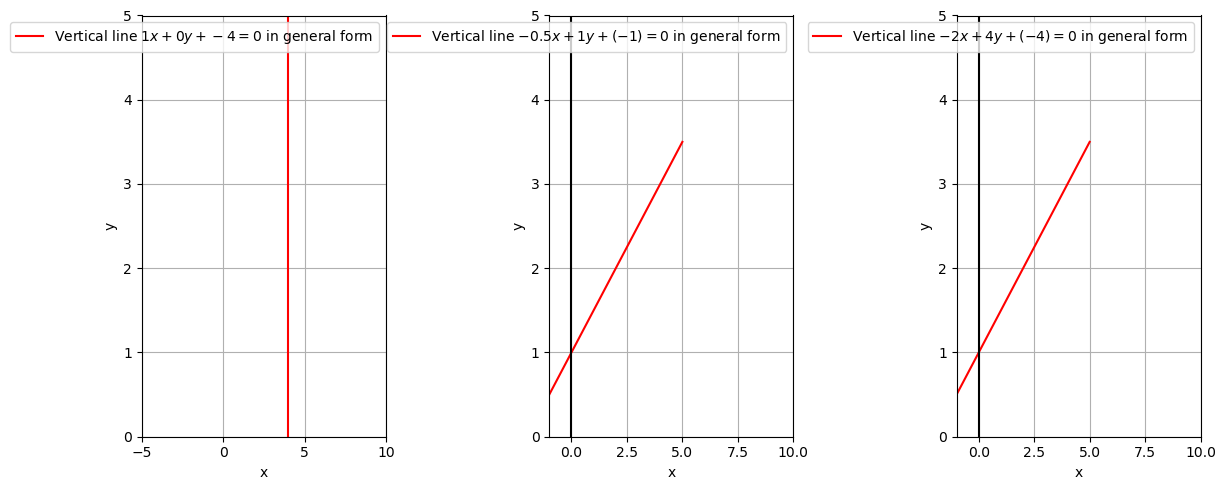

In [206]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
# Plot vertical line using general form
A, B, C = 1, 0, -4 # Ax + 0y + C = 0 
x = -C / A 
y = np.linspace(0, 10, 100)
x_vals = np.full_like(y, x) # repeats x len(y) times
plt.plot(x_vals, y,label=rf"Vertical line ${A}x+{B}y+{C}=0$ in general form",color="red")
plt.xlim(-5, 10)
plt.ylim(0,5)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.subplot(1,3,2)
# Plot line using general form
A,B,C = -0.5,1,-1 # Ax + By + C = 0
x_vals = np.linspace(-5,5,100)
y_vals = (-A/B)*x_vals + (-C/B)
plt.plot(x_vals, y_vals,label=rf"Vertical line ${A}x+{B}y+({C})=0$ in general form",color="red")
plt.xlim(-1, 10)
plt.ylim(0,5)
plt.axvline(0,color="black")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.subplot(1,3,3)
# Plot line using general form
A,B,C = -2,4,-4 # Ax + By + C = 0
x_vals = np.linspace(-5,5,100)
y_vals = (-A/B)*x_vals + (-C/B)
plt.plot(x_vals, y_vals,label=rf"Vertical line ${A}x+{B}y+({C})=0$ in general form",color="red")
plt.xlim(-1, 10)
plt.ylim(0,5)
plt.axvline(0,color="black")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.tight_layout()
plt.show()

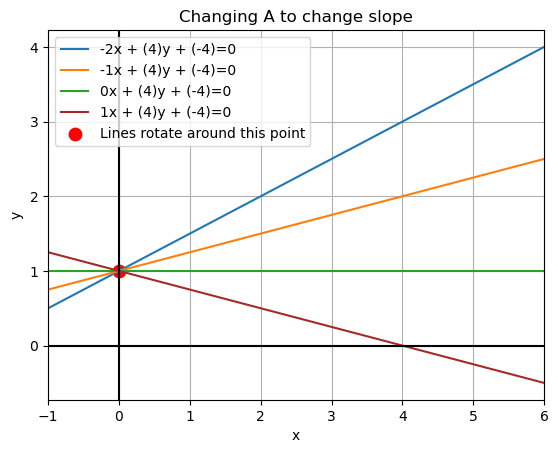

In [205]:
x = np.linspace(-2,6,100)
A,B,C = -2,4,-4
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -1,4,-4 # increased A / slope decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = 0,4,-4 # increased A / slope decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = 1,4,-4 # increased A / slope decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0",color="brown")

plt.scatter(0,-(C/B),color="red",label="Lines rotate around this point",s=80)

plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.title("Changing A to change slope")
plt.xlim(-1,np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

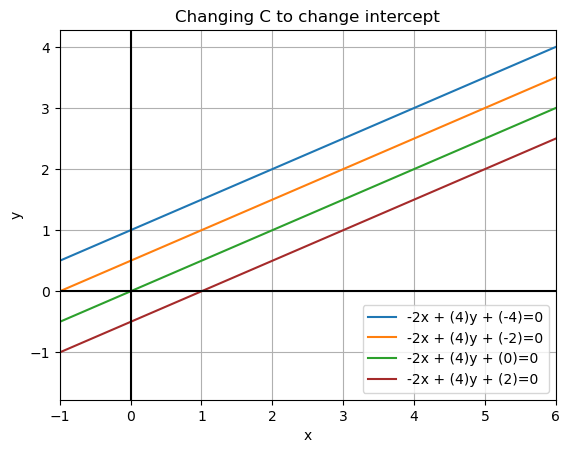

In [204]:
x = np.linspace(-2,6,100)
A,B,C = -2,4,-4
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,4,-2 # increased C / intercept decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,4,0 # increased C / intercept decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,4,2 # increased C / intercept decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0",color="brown")

plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.title("Changing C to change intercept")
plt.xlim(-1,np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

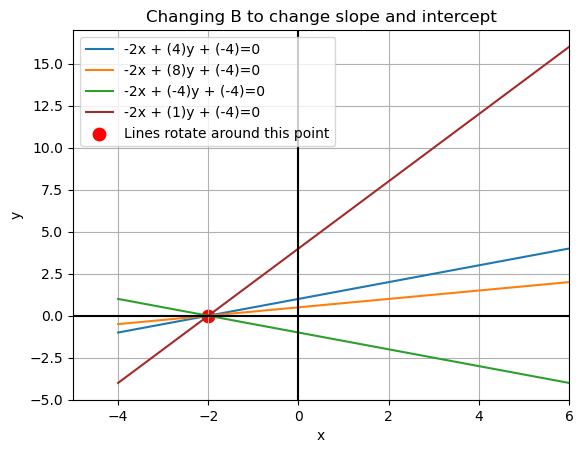

In [203]:
x = np.linspace(-4,6,100)
A,B,C = -2,4,-4
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,8,-4 # increased B 
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,-4,-4 # decreased B
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,1,-4 # decreased B
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0",color="brown")

plt.scatter(A,0,color="red",label="Lines rotate around this point",s=80)
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.title("Changing B to change slope and intercept")
plt.xlim(-5,np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

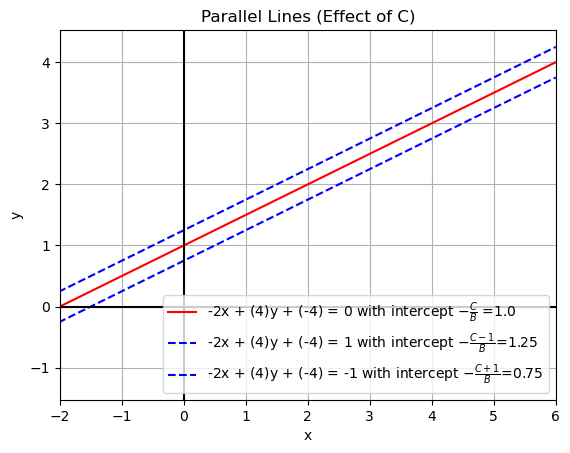

In [202]:
x = np.linspace(-4, 6, 100)

A, B = -2, 4

# original C
C0 = -4
y0 = -(A/B)*x - C0/B
plt.plot(x, y0, label=rf"{A}x + ({B})y + ({C0}) = 0 with intercept $-\frac{{C}}{{B}}$ ={-C0/B}",color="red")

# shifted line (C - 1)
C1 = C0 - 1
y1 = -(A/B)*x - C1/B
plt.plot(x, y1, label=rf"{A}x + ({B})y + ({C0}) = 1 with intercept $-\frac{{C-1}}{{B}}$={-(C0-1)/B}",color="blue",linestyle="--")

# shifted line (C + 1)
C2 = C0 + 1
y2 = -(A/B)*x - C2/B
plt.plot(x, y2, label=rf"{A}x + ({B})y + ({C0}) = -1 with intercept $-\frac{{C+1}}{{B}}$={-(C0+1)/B}",color="blue",linestyle="--")

plt.axvline(0, color="black")
plt.axhline(0, color="black")
plt.title("Parallel Lines (Effect of C)")
plt.xlim(-2, np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()



plt.show()

### Scaling constants $A,B$ and $C$

<div style="display:flex; gap:20px;">


<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
\begin{align*}
k(Ax + By + C) &= 0 \hspace{1 mm} \mid \hspace{1 mm} k \in \mathbb{R}_{>0} \\ \Leftrightarrow
kAx + kBy + kC &= 0 \\ \Leftrightarrow
kBy  &= -kAx - kC \\ \Leftrightarrow
ky  &= -\frac{kA}{B}x - \frac{kC}{B} \\ \Leftrightarrow
y  &= -\frac{A}{B}x - \frac{C}{B} \\ 
\end{align*} 
$$

- Scaling $Ax + By + C$ of $Ax + By + C=0$ with $k \in \mathbb{R}_{>0}$ does not change the line


</div>


<div style="
padding:16px;
border-radius:8px;
width:50%;
">
Case 1: Upper parallel dashed line

$$
\begin{align*}
k(Ax + By + C) &= 1 \hspace{1 mm} \mid \hspace{1 mm} k \in \mathbb{R}_{>0} \\ \Leftrightarrow
Ax + By + C &= \frac{1}{k} \\ \Leftrightarrow
Ax + By + \underbrace{C - \frac{1}{k}}_{\text{new constant}} &= 0 \\ 
\end{align*} 
$$
- new intercept is $-\frac{C - \frac{1}{k}}{B}=-\frac{C}{B} + \frac{1}{kB}$

    - If $k < 1$ then $\frac{1}{k} > 1$ so $\frac{1}{kB}$ is large and positive $\Rightarrow$ intercept increases a lot (line moves up fast ;if $B>0$ otherwise directions reverse)

    - If $k > 1$ then $\frac{1}{k} < 1$ so $\frac{1}{kB}$ is small and positive $\Rightarrow$ intercept increases slightly (line moves up slow ;if $B>0$ otherwise directions reverse)


Case 2: Lower parallel dashed line

$$
\begin{align*}
k(Ax + By + C) &= -1 \hspace{1 mm} \mid \hspace{1 mm} k > 0 \\ \Leftrightarrow
Ax + By + C &= -\frac{1}{k} \\ \Leftrightarrow
Ax + By + \underbrace{C + \frac{1}{k}}_{\text{new constant}} &= 0 \\ 
\end{align*} 
$$

- new intercept is $-\frac{C + \frac{1}{k}}{B}=-\frac{C}{B} - \frac{1}{kB}$

    - If $k < 1$ then $\frac{1}{k} > 1$ so $\frac{1}{kB}$ is large and negative $\Rightarrow$ intercept decreases a lot (line moves down fast ;if $B>0$ otherwise directions reverse)

    - If $k > 1$ then $\frac{1}{k} < 1$ so $\frac{1}{kB}$ is small and negative $\Rightarrow$ intercept decreases slightly (line moves down slow ;if $B>0$ otherwise directions reverse)


</div>
</div>

**Note: For k < 0 then $\frac{1}{k} < 0$ so "upper" line becomes "lower" and "lower" line becomes "upper".**

<p align="center">
<img src="pics/13.jpg" width="500"/>
</p>

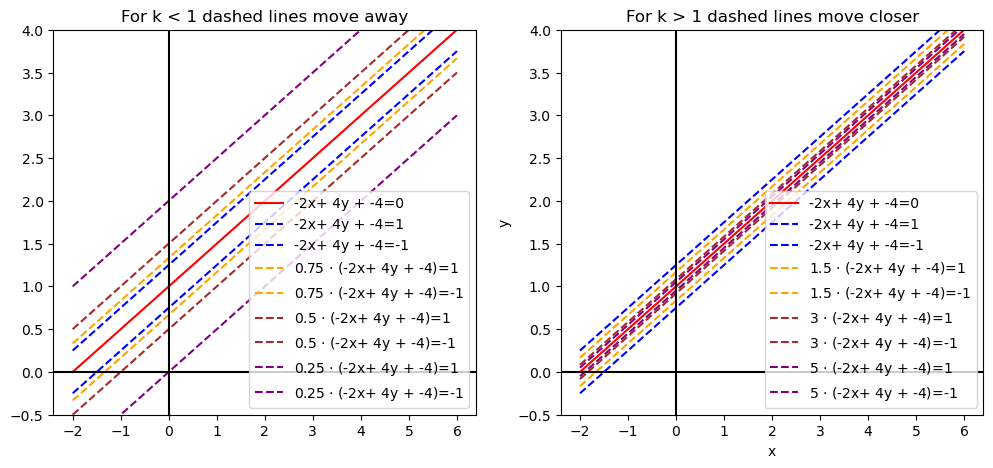

In [ ]:
x = np.linspace(-2,6,100)

A,B,C = -2,4,-4
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x,-(A/B)*x-(C/B),color="red",label=f"{A}x+ {B}y + {C}=0")
plt.plot(x,-(A/B)*x-((C-1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=1")
plt.plot(x,-(A/B)*x-((C+1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=-1")

for k,color in zip([0.75,0.5,0.25],["orange", "brown","purple"]):
    plt.plot(x,-(A/B)*x-((C-1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=1",color=color)
    plt.plot(x,-(A/B)*x-((C+1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=-1",color=color)

plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.ylim((-0.5,4))
plt.xlabel("x")
plt.ylabel("y")
plt.title("For k < 1 dashed lines move away")
plt.legend()


plt.subplot(1,2,2)
plt.plot(x,-(A/B)*x-(C/B),color="red",label=f"{A}x+ {B}y + {C}=0")
plt.plot(x,-(A/B)*x-((C-1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=1")
plt.plot(x,-(A/B)*x-((C+1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=-1")

for k,color in zip([1.5,3,5],["orange", "brown","purple"]):
    plt.plot(x,-(A/B)*x-((C-1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=1",color=color)
    plt.plot(x,-(A/B)*x-((C+1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=-1",color=color)

plt.legend()
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.ylim((-0.5,4))
plt.xlabel("x")
plt.ylabel("y")
plt.title("For k > 1 dashed lines move closer")


plt.show()

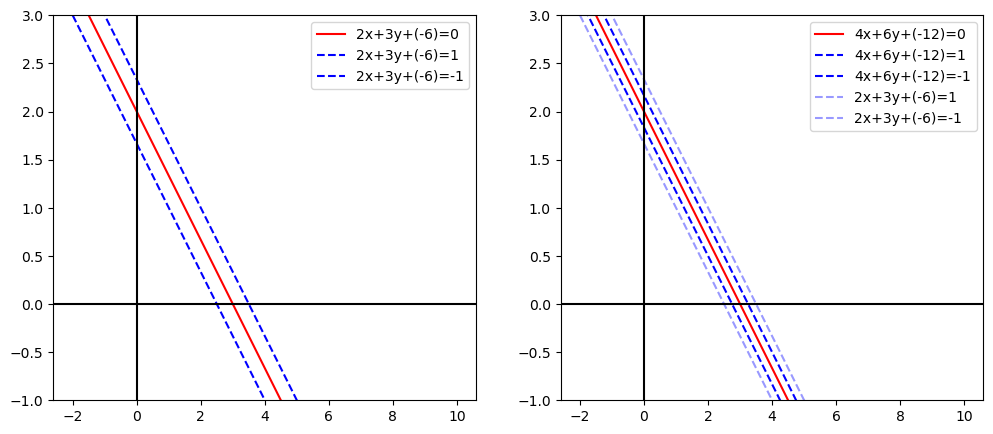

In [ ]:
x = np.linspace(-2,10,100)

A,B,C = 2,3,-6

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{A}x+{B}y+({C})=0")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--")
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.subplot(1,2,2)
k = 2
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{k*A}x+{k*B}y+({k*C})=0")
plt.plot(x,(-A/B)*x - (C-1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=-1",linestyle="--")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--",alpha=0.4)
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--",alpha=0.4)
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.show()

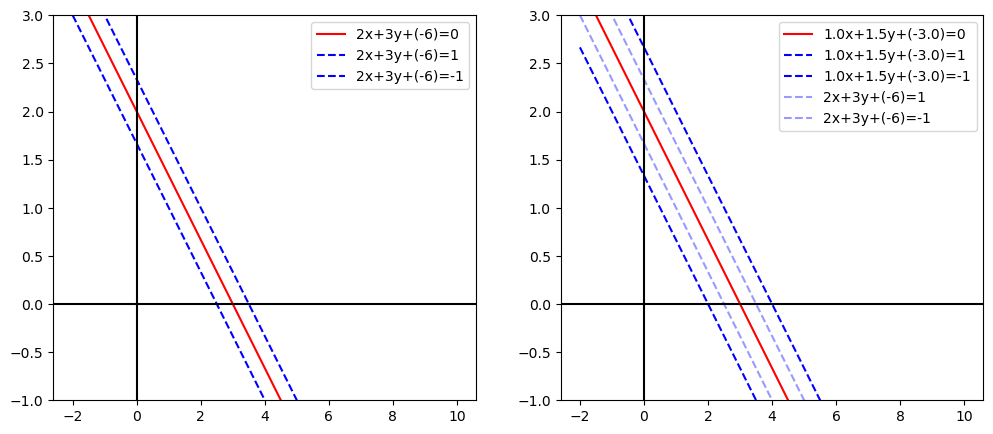

In [218]:
x = np.linspace(-2,10,100)

A,B,C = 2,3,-6

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{A}x+{B}y+({C})=0")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--")
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.subplot(1,2,2)
k = 0.5
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{k*A}x+{k*B}y+({k*C})=0")
plt.plot(x,(-A/B)*x - (C-1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=-1",linestyle="--")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--",alpha=0.4)
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--",alpha=0.4)
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.show()

### Distance between a point $(x_0,y_0)$ and a ponit on the line $Ax_0 + By_0 + C = z$

$$
\text{distance} = \frac{\mid Ax_0 + By_0 + (C-z) \mid}{\sqrt{A^2 + B^2}}
$$

<p align="center">
<img src="pics/9.jpg" width="500"/>
</p>

### Distance between two parallel lines $Ax + By + C = z$ and $Ax + By + C = z'$

$$
\text{distance} = \frac{\mid Ax + By + (C-z) - (Ax + By + (C-z'))\mid}{\sqrt{A^2 + B^2}} = \frac{\mid z -  z'\mid}{\sqrt{A^2 + B^2}}
$$


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/10.jpg" width="500"/>
  <img src="pics/11.jpg" width="500"/>
</div>

<a class="anchor" id="idea"></a>
# 1. Intrioduction

## Idea 1

- Use the general equation form to express decision boundariess either as lines, planes or hyperplanes
- Example in 2d: Express $y=mx+b$ as $Ax+By+C=0$


## Idea 2
- Separate classes based on the distance to the closest points.
- Here is an exapmle in 2d

<p align="center">
<img src="pics/17.jpg" width="500"/>
</p>

- Now we not only require the decision boundary $Ax+By+C=0$ but also the safety margins $Ax+By+C=z$ and $Ax+By+C=-z$. 


## Idea 3
- It is apparent that we want to maximize the with of the safety margins
- For that we need to derive the precise equation of the decision boundary
- Again we see how this works in 2d

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/18.jpg" width="500"/>
  <img src="pics/19.jpg" width="500"/>
</div>


## Idea 4
- In SVM the value for $z$ is 1
- The reason for this is the scaling invariance of the lines
- $w^\top x + b=z$ and $kw^\top x + kb=kz$ $(k \neq 0)$ describe the same decision boundary and the same goes for  $w^\top x + b=z$ and $\frac{w^\top x}{z} +\frac{b}{z}=\frac{z}{z}=1$
- We specifically choose to rescale to 1 because it gives a canonical (standardized) representation
    - The closest points (support vectors) satisfy:
    $$
    w^\top x^{(i)} + b = \begin{cases}
    1 & \text{if } x^{(i)} \text{ is above the decision boundary} \\
    -1 & \text{if } x^{(i)} \text{ is below the decision boundary}
    \end{cases}
    $$
    - This makes the margin width clean:
    $$
    \text{margin width}=\frac{2}{\lVert w \rVert}
    $$
<p align="center">
<img src="pics/20.jpg" width="500"/>
</p>

## Conclusion
<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/21.jpg" width="500"/>
  <img src="pics/22.jpg" width="500"/>
</div>


## How do Support Vectors arise?

Start with any separating solution: $$y^{(i)}(w^\top \cdot  x^{(i)} + b)$$
Now define: $$\gamma = \min_i y^{(i)}(w\top \cdot x^{(i)} + b)$$
This is the smallest functional margin. Now rescale:

$$w' = \frac{w}{\gamma}, \quad b' = \frac{b}{\gamma}$$
Then: $$y^{(i)}(w'^\top \cdot x^{(i)} + b') \geq 1$$

&#128073; and for at least one point: $$y^{(i)}(w'^\top \cdot x^{(i)} + b') = 1$$

and we call that data point $x^{(i)}$ a support vector (SV).

**We consider all separating hyperplanes and minimize $\lvert w \rVert$. If the smallest value $y^{(i)}(w^\top \cdot  x^{(i)} + b)$ is greater than 1, we can rescale $(w,b)$ down to further reduce $\lvert w \rVert$ without changing the decision boundary.Therefore, at the optimum, the smallest value must be exactly 1.The points achieving this minimum are the support vectors.**




<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/14.jpg" width="500"/>
  <img src="pics/15.jpg" width="500"/>
</div>

Before scaling:
Positive: [4 6]
Negative: [-4 -6]
Closest value: 4

After scaling:
Positive: [1.  1.5]
Negative: [-1.  -1.5]
Closest value: 1.0


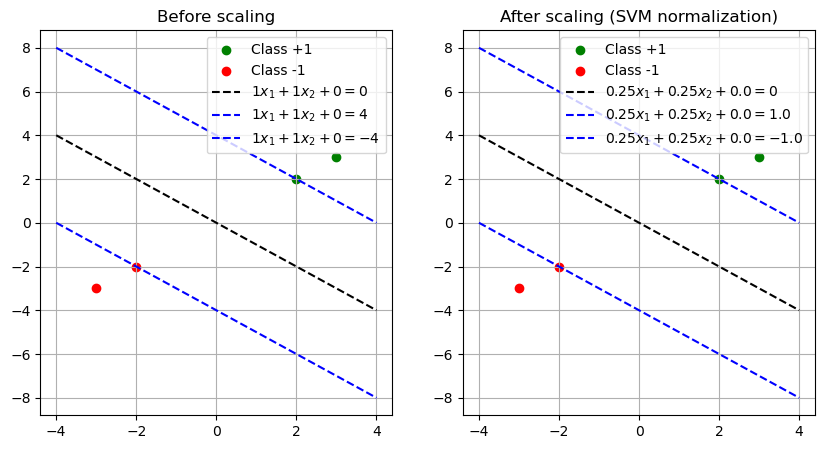

In [265]:
# Data 
X_pos = np.array([[2,2],[3,3]])
X_neg = np.array([[-2,-2],[-3,-3]])

# Step 1: initial separator 
w = np.array([1,1])
b = 0

def f(x, w, b):
    return x @ w + b

# compute values
vals_pos = f(X_pos, w, b)
vals_neg = f(X_neg, w, b)

print("Before scaling:")
print("Positive:", vals_pos)
print("Negative:", vals_neg)

# Step 2: find closest points (support vectors)
closest_val = min(np.min(np.abs(vals_pos)), np.min(np.abs(vals_neg)))
print("Closest value:", closest_val)

# Step 3: rescale 
w_scaled = w / closest_val
b_scaled = b / closest_val

# compute new values
vals_pos_scaled = f(X_pos, w_scaled, b_scaled)
vals_neg_scaled = f(X_neg, w_scaled, b_scaled)

print("\nAfter scaling:")
print("Positive:", vals_pos_scaled)
print("Negative:", vals_neg_scaled)

closest_val_scaled = min(np.min(np.abs(vals_pos_scaled)), np.min(np.abs(vals_neg_scaled)))
print("Closest value:", closest_val_scaled)

# Plot 
x = np.linspace(-4,4,100)

def line(x, w, b, c):
    # w1*x1 + w2*x2 + b = c  → x2 = ...
    return (-w[0]*x - b + c)/w[1]

plt.figure(figsize=(10,5))

# Before scaling
plt.subplot(1,2,1)
plt.scatter(X_pos[:,0], X_pos[:,1], color='green', label='Class +1')
plt.scatter(X_neg[:,0], X_neg[:,1], color='red', label='Class -1')

plt.plot(x, line(x,w,b,0), 'k--', label=rf'${w[0]}x_1 + {w[1]}x_2 + {b} = 0$')
plt.plot(x, line(x,w,b,closest_val), 'b--', label=rf'${w[0]}x_1 + {w[1]}x_2 + {b} = {closest_val}$')
plt.plot(x, line(x,w,b,-closest_val), 'b--', label=rf'${w[0]}x_1 + {w[1]}x_2 + {b} = {-closest_val}$')

plt.title("Before scaling")
plt.legend()
plt.grid()

# After scaling
plt.subplot(1,2,2)
plt.scatter(X_pos[:,0], X_pos[:,1], color='green', label='Class +1')
plt.scatter(X_neg[:,0], X_neg[:,1], color='red', label='Class -1')

plt.plot(x, line(x,w_scaled,b_scaled,0), 'k--', label=rf'${w_scaled[0]}x_1 + {w_scaled[1]}x_2 + {b_scaled} = 0$')
plt.plot(x, line(x,w_scaled,b_scaled,1), 'b--', label=rf'${w_scaled[0]}x_1 + {w_scaled[1]}x_2 + {b_scaled} = {closest_val_scaled}$')
plt.plot(x, line(x,w_scaled,b_scaled,-1), 'b--', label=rf'${w_scaled[0]}x_1 + {w_scaled[1]}x_2 + {b_scaled} = {-closest_val_scaled}$')

plt.title("After scaling (SVM normalization)")
plt.legend()
plt.grid()

plt.show()

<a class="anchor" id="optim"></a>
# 2. Constrained optimization problems

<a class="anchor" id="implement"></a>
# 3. Implement linear separable SVM

# <u>SVM-Linearly non-separable case</u>

## Topics

* [1. ](#)